In [6]:
from sparseDPD import DataManager, DatapathPruningExperiment
from sparseDPD import Datapath
from sparseDPD import NeuralNetwork
from sparseDPD import PGJANET_NeuralNetwork
from sparseDPD import PNTDNN_NeuralNetwork
from sparseDPD import AdaptiveDatapathPruningExperiment

Using cuda device
Using cuda device
Epoch  10/50  Loss=8.0684e+00  Valid Loss=1.4551e+01  LR=1.00e-03
Epoch  20/50  Loss=5.6548e+00  Valid Loss=1.1494e+01  LR=1.00e-03
Epoch  30/50  Loss=4.2413e+00  Valid Loss=8.5341e+00  LR=1.00e-03
Epoch  40/50  Loss=3.2663e+00  Valid Loss=6.2529e+00  LR=1.00e-03
Epoch  50/50  Loss=2.8457e+00  Valid Loss=5.0543e+00  LR=1.00e-03

Best model from epoch 50 with validation loss: 5.0543e+00
Epoch  10/50  Loss=9.6732e-01  Valid Loss=4.9196e-01  LR=1.00e-03
Epoch  20/50  Loss=4.7344e-01  Valid Loss=2.1341e-01  LR=1.00e-03
Epoch  30/50  Loss=3.8831e-01  Valid Loss=1.4521e-01  LR=1.00e-03
Epoch  40/50  Loss=3.6564e-01  Valid Loss=1.2304e-01  LR=1.00e-03
Epoch  50/50  Loss=3.5589e-01  Valid Loss=1.1262e-01  LR=1.00e-03

Best model from epoch 50 with validation loss: 1.1262e-01
Epoch  10/50  Loss=2.3145e-01  Valid Loss=3.0205e-02  LR=1.00e-03
Epoch  20/50  Loss=2.1226e-01  Valid Loss=2.7459e-02  LR=1.00e-03
Epoch  30/50  Loss=2.0580e-01  Valid Loss=2.6072e-02  

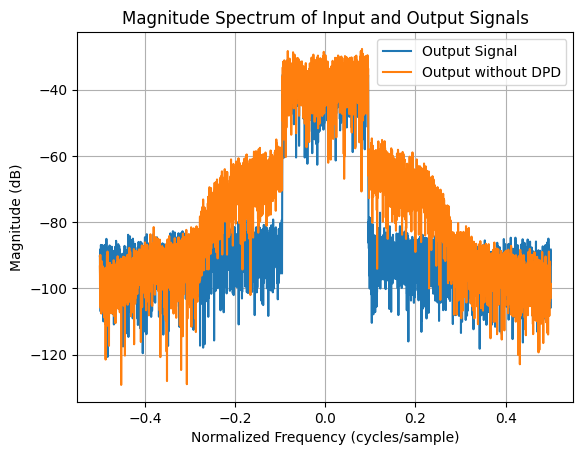

In [7]:
# load pretrained model
simpleDataManager = DataManager(filepath='UCD_datasets/PA_IO.mat', num_training_points=19000, num_validaiton_points=1000, num_test_points=2000)

PGJANET_forward_nn = PGJANET_NeuralNetwork(nn_file_path='pre_trained_models/pgjanet_checkpoint.pt', num_memory_levels=10, model_type='PGJANETNetwork', forward_model=True)

# Train PNTDNN inverse model, but dont train yet. Use ILA training instead
PNTDNN_inverse_nn = PNTDNN_NeuralNetwork(num_memory_levels=15, model_type='OneLayerNetwork', forward_model=False)


datapath = Datapath(forward_model=PGJANET_forward_nn, inverse_model=PNTDNN_inverse_nn)
datapath.train_using_ila(
    training_dataset = simpleDataManager.training_dataset,
    valid_dataset = simpleDataManager.validation_dataset,
    iterations = 5,
    retrain_epochs_per_iteration=50
)

# find nmse
nmse = datapath.calculate_nmse(simpleDataManager.test_dataset.input_data)
print(f"NMSE: {nmse:.4f} dB")

# Plot the spectrum 
datapath.plot_spectrum(simpleDataManager.test_dataset.input_data[:5000])

Your inverse model is type <class 'sparseDPD.PNTDNN.PNTDNN_NeuralNetwork'> and your forward model is type <class 'sparseDPD.PGJANET.PGJANET_NeuralNetwork'>
ACLR with DPD - Lower: 33.90 dBc, Upper: 42.72 dBc
ACLR without DPD - Lower: 28.12 dBc, Upper: 27.79 dBc
Your inverse model is type <class 'sparseDPD.PNTDNN.PNTDNN_NeuralNetwork'> and your forward model is type <class 'sparseDPD.PGJANET.PGJANET_NeuralNetwork'>
Your inverse model is type <class 'sparseDPD.PNTDNN.PNTDNN_NeuralNetwork'> and your forward model is type <class 'sparseDPD.PGJANET.PGJANET_NeuralNetwork'>


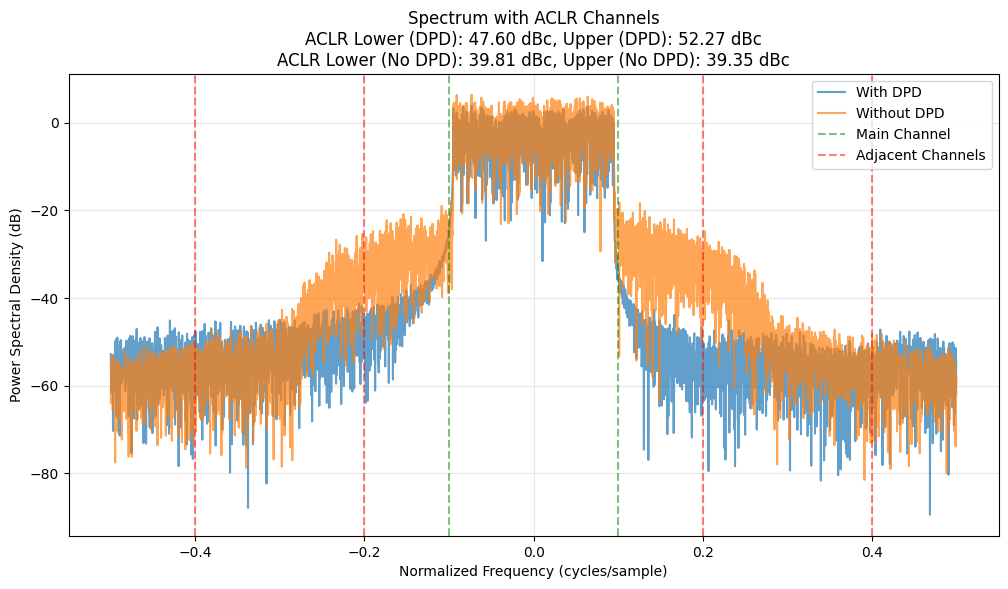

In [3]:
# Calculate ACLR metrics
aclr_results = datapath.calculate_aclr(
    simpleDataManager.test_dataset.input_data[:5000],
    channel_bw=0.1,        # Main channel bandwidth (10% of fs)
    channel_spacing=0.15,   # Adjacent channel offset (15% of fs)
    fs=1.0                  # Normalized sampling frequency
)

print(f"ACLR with DPD - Lower: {aclr_results['aclr_lower_dpd']:.2f} dBc, Upper: {aclr_results['aclr_upper_dpd']:.2f} dBc")
print(f"ACLR without DPD - Lower: {aclr_results['aclr_lower_no_dpd']:.2f} dBc, Upper: {aclr_results['aclr_upper_no_dpd']:.2f} dBc")

# Plot spectrum with ACLR channel boundaries marked
datapath.plot_spectrum_with_aclr(
    simpleDataManager.test_dataset.input_data[:5000],
    channel_bw=0.2,
    channel_spacing=0.3
)

Your inverse model is type <class 'sparseDPD.PNTDNN.PNTDNN_NeuralNetwork'> and your forward model is type <class 'sparseDPD.PGJANET.PGJANET_NeuralNetwork'>
Your inverse model is type <class 'sparseDPD.PNTDNN.PNTDNN_NeuralNetwork'> and your forward model is type <class 'sparseDPD.PGJANET.PGJANET_NeuralNetwork'>

Pruning Iteration 1/10
Pruning 20.0% of remaining weights...
Current pruning: 20.00% of weights are zero
Retraining for 50 epochs...
Epoch  10/50  Loss=9.9191e-02  Valid Loss=8.1207e-03  LR=1.00e-03
Epoch  20/50  Loss=5.9475e-02  Valid Loss=6.6425e-03  LR=5.00e-04
Epoch  30/50  Loss=5.8610e-02  Valid Loss=7.2111e-03  LR=5.00e-04
Epoch  40/50  Loss=5.5240e-02  Valid Loss=6.3301e-03  LR=2.50e-04
Epoch  50/50  Loss=5.3563e-02  Valid Loss=6.6416e-03  LR=1.25e-04

Best model from epoch 38 with validation loss: 6.3107e-03
Epoch  10/50  Loss=6.8405e-02  Valid Loss=8.2946e-03  LR=1.00e-03
Epoch  20/50  Loss=6.8784e-02  Valid Loss=8.1436e-03  LR=1.00e-03
Epoch  30/50  Loss=8.5678e-02  Va

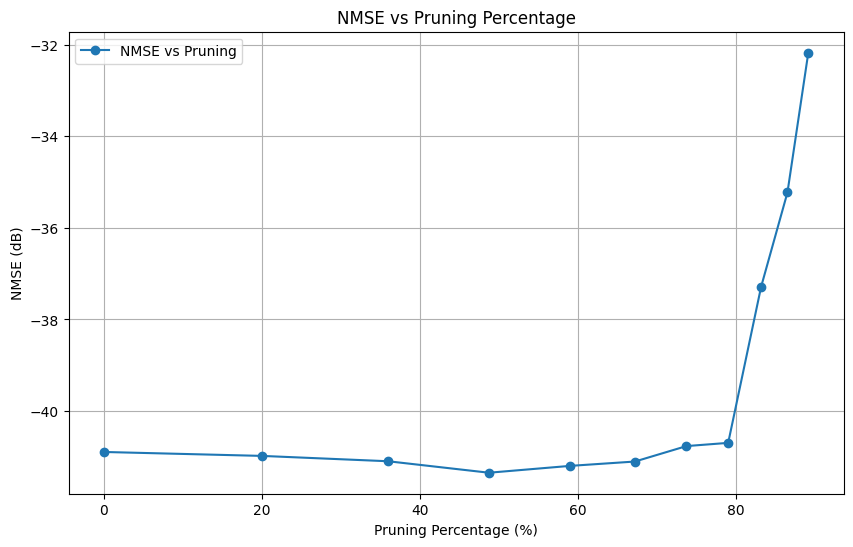

Your inverse model is type <class 'sparseDPD.PNTDNN.PNTDNN_NeuralNetwork'> and your forward model is type <class 'sparseDPD.PGJANET.PGJANET_NeuralNetwork'>
Best NMSE after pruning: -40.6946 dB


In [4]:
# Now run the pruning experiment
pruning_experiment = DatapathPruningExperiment(
    datapath=datapath,
    training_dataset=simpleDataManager.training_dataset,
    validation_dataset=simpleDataManager.validation_dataset,
    test_dataset=simpleDataManager.test_dataset,
    num_prune_iterations=10,
    prune_amount=0.2,
    retrain_epochs=50,
    ila_iterations = 5
)

pruning_experiment.run()

print("Best NMSE after pruning: {:.4f} dB".format(pruning_experiment.best_datapath.calculate_nmse(simpleDataManager.test_dataset.input_data)))

Your inverse model is type <class 'sparseDPD.PNTDNN.PNTDNN_NeuralNetwork'> and your forward model is type <class 'sparseDPD.PGJANET.PGJANET_NeuralNetwork'>
Best NMSE after pruning: -40.6946 dB
Best model sparsity level: 79.03%
Your inverse model is type <class 'sparseDPD.PNTDNN.PNTDNN_NeuralNetwork'> and your forward model is type <class 'sparseDPD.PGJANET.PGJANET_NeuralNetwork'>
Your inverse model is type <class 'sparseDPD.PNTDNN.PNTDNN_NeuralNetwork'> and your forward model is type <class 'sparseDPD.PGJANET.PGJANET_NeuralNetwork'>


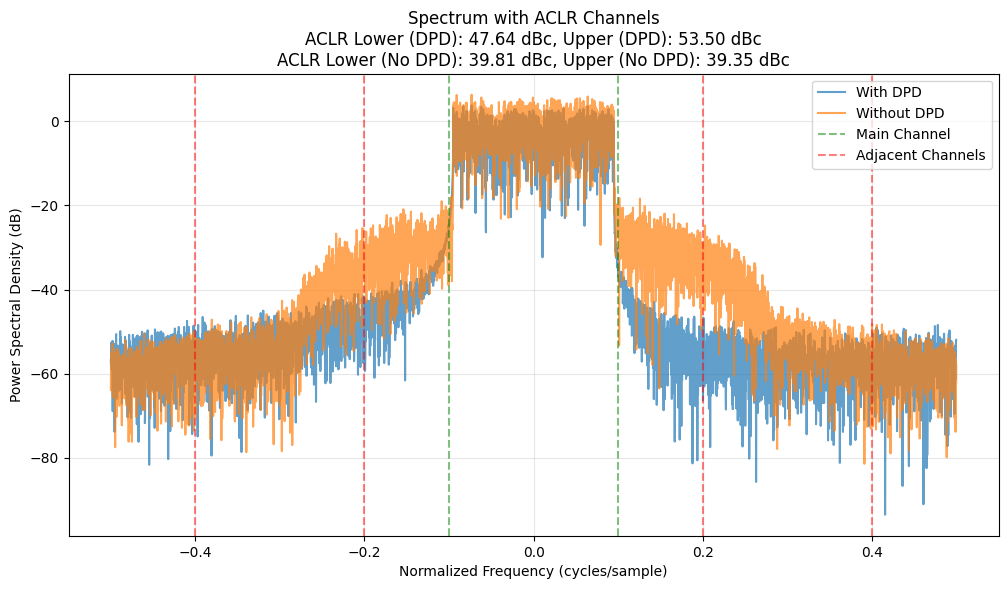

In [10]:
best_datapath = pruning_experiment.best_datapath
best_nmse = best_datapath.calculate_nmse(simpleDataManager.test_dataset.input_data)
print(f"Best NMSE after pruning: {best_nmse:.4f} dB")

# find the best model sparsity level
best_sparsity = best_datapath.inverse_model._get_pruning_percentage()
print(f"Best model sparsity level: {best_sparsity:.2f}%")

# Plot spectrum with ACLR channel boundaries marked
best_datapath.plot_spectrum_with_aclr(
    simpleDataManager.test_dataset.input_data[:5000],
    channel_bw=0.2,
    channel_spacing=0.3
)

Your inverse model is type <class 'sparseDPD.PNTDNN.PNTDNN_NeuralNetwork'> and your forward model is type <class 'sparseDPD.PGJANET.PGJANET_NeuralNetwork'>
Your inverse model is type <class 'sparseDPD.PNTDNN.PNTDNN_NeuralNetwork'> and your forward model is type <class 'sparseDPD.PGJANET.PGJANET_NeuralNetwork'>

Step 1  |  fraction = 50.00%
Pruning 50.00% of remaining weights...
Current sparsity: 50.00% of weights are zero
Retraining for 50 epochs...
Epoch  10/50  Loss=8.9030e-02  Valid Loss=8.0651e-03  LR=1.00e-03
Epoch  20/50  Loss=8.3608e-02  Valid Loss=7.8833e-03  LR=1.00e-03
Epoch  30/50  Loss=8.4533e-02  Valid Loss=7.5331e-03  LR=1.00e-03
Epoch  40/50  Loss=8.3616e-02  Valid Loss=7.4874e-03  LR=1.00e-03
Epoch  50/50  Loss=8.2297e-02  Valid Loss=7.4253e-03  LR=1.00e-03

Best model from epoch 50 with validation loss: 7.4253e-03
Epoch  10/50  Loss=8.0920e-02  Valid Loss=6.9908e-03  LR=1.00e-03
Epoch  20/50  Loss=6.8717e-02  Valid Loss=6.9320e-03  LR=5.00e-04
Epoch  30/50  Loss=6.5886

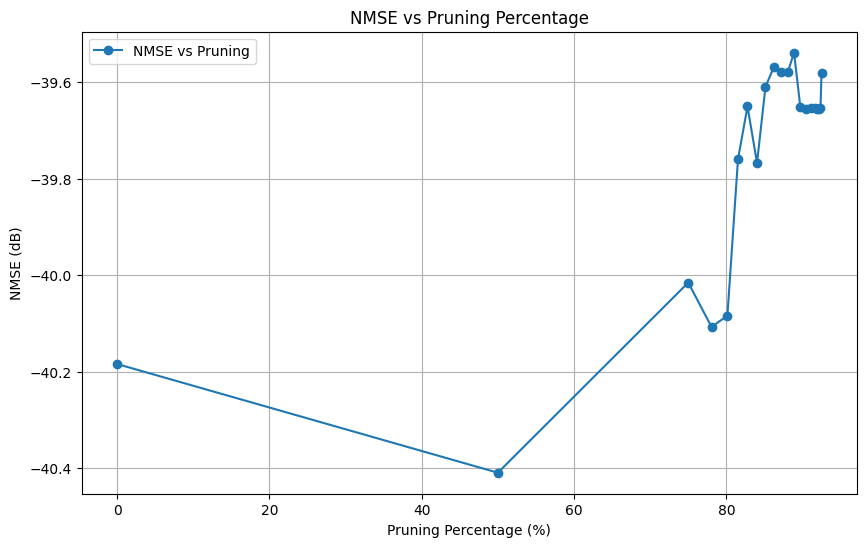

Your inverse model is type <class 'sparseDPD.PNTDNN.PNTDNN_NeuralNetwork'> and your forward model is type <class 'sparseDPD.PGJANET.PGJANET_NeuralNetwork'>
Best NMSE after pruning: -39.5810 dB


In [10]:
adaptive_pruning_experiment = AdaptiveDatapathPruningExperiment(
    datapath=datapath,
    training_dataset=simpleDataManager.training_dataset,
    validation_dataset=simpleDataManager.validation_dataset,
    test_dataset=simpleDataManager.test_dataset,
    num_prune_iterations=10,
    prune_amount=0.2,
    retrain_epochs=50,
    ila_iterations = 5,
    initial_prune_fraction=0.5,
    max_prune_fraction=0.5,
    min_prune_fraction=0.01
)

adaptive_pruning_experiment.run()

print("Best NMSE after pruning: {:.4f} dB".format(adaptive_pruning_experiment.best_datapath.calculate_nmse(simpleDataManager.test_dataset.input_data)))

Your inverse model is type <class 'sparseDPD.PNTDNN.PNTDNN_NeuralNetwork'> and your forward model is type <class 'sparseDPD.PGJANET.PGJANET_NeuralNetwork'>
Best NMSE after pruning: -39.5810 dB
Best model sparsity level: 92.50%
Your inverse model is type <class 'sparseDPD.PNTDNN.PNTDNN_NeuralNetwork'> and your forward model is type <class 'sparseDPD.PGJANET.PGJANET_NeuralNetwork'>
Your inverse model is type <class 'sparseDPD.PNTDNN.PNTDNN_NeuralNetwork'> and your forward model is type <class 'sparseDPD.PGJANET.PGJANET_NeuralNetwork'>


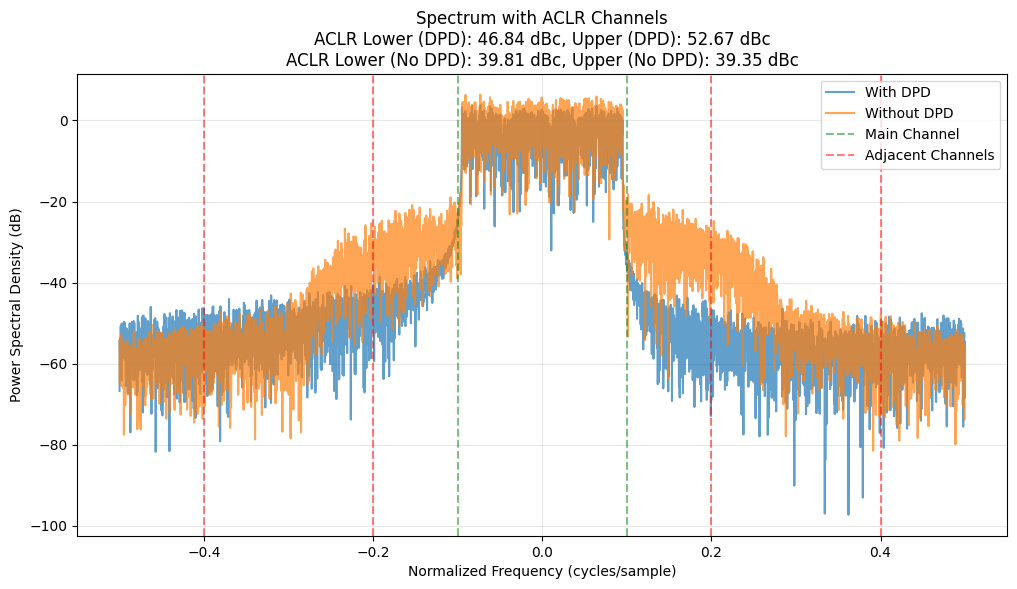

In [11]:
# Plot the spectrum of the best model
best_datapath = adaptive_pruning_experiment.best_datapath
best_nmse = best_datapath.calculate_nmse(simpleDataManager.test_dataset.input_data)
print(f"Best NMSE after pruning: {best_nmse:.4f} dB")

# find the best model sparsity level
best_sparsity = best_datapath.inverse_model._get_pruning_percentage()
print(f"Best model sparsity level: {best_sparsity:.2f}%")

# Plot spectrum with ACLR channel boundaries marked
best_datapath.plot_spectrum_with_aclr(
    simpleDataManager.test_dataset.input_data[:5000],
    channel_bw=0.2,
    channel_spacing=0.3
)